# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within each band (`merge_lst_metacatalog`).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
OUTPUT_DIR = Path("/fast/claw/metacatalog")  # Parquet catalog tree

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=7.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
fits_files = discover_fits_files(FITS_ROOT)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 80 FITS files under /fast/claw
LST hours from discovery (20): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h
LST hours in use (all discovered): 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h


,path,lst_hour,band,time_key
0,I_01h_deep_Taper_R0_Blue.fits,01h,Blue,None
1,I_01h_deep_Taper_R0_Full.fits,01h,Full,None
2,I_01h_deep_Taper_R0_Green.fits,01h,Green,None
3,I_01h_deep_Taper_R0_Red.fits,01h,Red,None
4,I_02h_deep_Taper_R0_Blue.fits,02h,Blue,None
...,...,...,...,...
75,I_19h_deep_Taper_R0_Red.fits,19h,Red,None
76,I_20h_deep_Taper_R0_Blue.fits,20h,Blue,None
77,I_20h_deep_Taper_R0_Full.fits,20h,Full,None
78,I_20h_deep_Taper_R0_Green.fits,20h,Green,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "E_RA",
    "E_DEC",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "E_Maj",
    "Min",
    "E_Min",
    "PA",
    "E_PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "S_Code",
    "Gaus_id",
    "Isl_id",
    "Source_id",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


Cached ('01h', 'Blue'): 3843 sources <- sources_01h_Blue.parquet
Cached ('01h', 'Full'): 2479 sources <- sources_01h_Full.parquet
Cached ('01h', 'Green'): 2475 sources <- sources_01h_Green.parquet
Cached ('01h', 'Red'): 975 sources <- sources_01h_Red.parquet
Cached ('02h', 'Blue'): 3908 sources <- sources_02h_Blue.parquet
Cached ('02h', 'Full'): 2160 sources <- sources_02h_Full.parquet
Cached ('02h', 'Green'): 1997 sources <- sources_02h_Green.parquet
Cached ('02h', 'Red'): 798 sources <- sources_02h_Red.parquet
Cached ('03h', 'Blue'): 3952 sources <- sources_03h_Blue.parquet
Cached ('03h', 'Full'): 2277 sources <- sources_03h_Full.parquet
Cached ('03h', 'Green'): 1982 sources <- sources_03h_Green.parquet
Cached ('03h', 'Red'): 774 sources <- sources_03h_Red.parquet
Cached ('04h', 'Blue'): 3976 sources <- sources_04h_Blue.parquet
Cached ('04h', 'Full'): 2333 sources <- sources_04h_Full.parquet
Cached ('04h', 'Green'): 2052 sources <- sources_04h_Green.parquet
Cached ('04h', 'Red'): 755

## Metacatalog fusion

LST merge within each band, then sequential Full→Blue→Green→Red association
(`lwa_catalog.create.merge`). `BAND_FIELDS` / `ASSOC_BANDS` / `COLOR_BANDS` are
notebook constants.


In [6]:
BAND_FIELDS = (
    "Peak_flux",
    "Total_flux",
    "RA",
    "DEC",
    "Maj",
    "Min",
    "PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
)


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (Full): loaded 9390 sources from metacatalog_lst_Full.parquet
LST merge (Blue): loaded 15455 sources from metacatalog_lst_Blue.parquet
LST merge (Green): loaded 11051 sources from metacatalog_lst_Green.parquet
LST merge (Red): loaded 3579 sources from metacatalog_lst_Red.parquet

Global metacatalog: 18396 sources from 188232 per-image detections
Wrote /fast/claw/metacatalog_old/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,PA_Red,DC_Maj_Red,DC_Min_Red,DC_PA_Red,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red
0,18226,Red,Red,-173.098968,1.812380,144.332514,338.369942,0.406568,0.370945,44.459379,...,44.459379,0.331178,0.251753,44.166704,1,NaN,NaN,NaN,NaN,I_13h_deep_Taper_R0_Red.fits
1,0,Full,"Full,Blue,Green,Red",-107.238944,5.016084,106.613063,25.235860,0.147784,0.035818,6.617722,...,42.492662,0.342648,0.183134,43.553086,1,0.126782,I_14h_deep_Taper_R0_Full.fits,I_14h_deep_Taper_R0_Blue.fits,I_14h_deep_Taper_R0_Green.fits,I_18h_deep_Taper_R0_Red.fits
2,1,Full,"Full,Blue,Green,Red",-75.888939,1.413500,93.911683,365.995326,0.321150,0.304488,162.788162,...,21.054388,0.452130,0.307522,19.657056,1,0.141524,I_17h_deep_Taper_R0_Full.fits,I_18h_deep_Taper_R0_Blue.fits,I_20h_deep_Taper_R0_Green.fits,I_20h_deep_Taper_R0_Red.fits
3,2,Full,"Full,Blue,Green,Red",-76.099275,1.431913,89.495130,418.045659,0.480534,0.236417,21.934136,...,21.054388,0.452130,0.307522,19.657056,1,0.141524,I_17h_deep_Taper_R0_Full.fits,I_17h_deep_Taper_R0_Blue.fits,I_18h_deep_Taper_R0_Green.fits,I_20h_deep_Taper_R0_Red.fits
4,15388,Green,"Green,Red",-113.546620,39.418069,88.662391,218.275153,0.265586,0.235030,67.183443,...,87.221405,0.347720,0.275950,88.656028,1,NaN,NaN,NaN,I_13h_deep_Taper_R0_Green.fits,I_13h_deep_Taper_R0_Red.fits
5,18227,Red,Red,-134.356132,26.007790,88.123435,219.765721,0.427205,0.316307,60.489544,...,60.489544,0.349088,0.227245,60.600641,1,NaN,NaN,NaN,NaN,I_13h_deep_Taper_R0_Red.fits
6,18228,Red,Red,-130.044190,7.692659,87.729867,222.882199,0.500202,0.325030,48.447896,...,48.447896,0.405597,0.240525,47.945872,1,NaN,NaN,NaN,NaN,I_13h_deep_Taper_R0_Red.fits
7,15389,Green,Green,82.748179,21.414618,84.581035,26.093448,0.298832,0.143407,155.586323,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,I_11h_deep_Taper_R0_Green.fits,NaN
8,15390,Green,Green,-131.219534,6.773384,80.949591,189.760182,0.313080,0.199765,39.835370,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,I_13h_deep_Taper_R0_Green.fits,NaN
9,15391,Green,Green,-100.671440,-0.866199,80.284313,212.440315,0.464697,0.384139,22.003461,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,I_13h_deep_Taper_R0_Green.fits,NaN


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")
metacatalog.head(10)[["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "n_assoc_Blue", "n_assoc_Green", "n_assoc_Red"]]

Full-band sources after LST merge: 9390
  seen in multiple LST hours: 8184


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
17,69.419237,29.759111,42.234336,47,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",05h
52,83.551798,21.939245,28.757528,41,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12h",05h
20,6.317399,64.134317,37.989208,37,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",08h
0,-107.238944,5.016084,106.613063,35,"12h,14h,15h,16h,17h,18h,19h,20h",14h
61,280.518634,79.774148,27.682969,32,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",03h
12,49.940296,41.511079,46.298816,31,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,20h",06h
7,-99.876971,-1.072769,55.098299,30,"12h,14h,15h,16h,17h,18h,19h,20h",18h
6,187.679198,12.362105,59.555444,29,"06h,07h,08h,09h,11h,14h,15h,16h,17h,18h",08h
50,140.314849,45.644427,29.035553,29,"02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12h,14...",03h
45,35.796196,86.315823,29.796242,28,"01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h,12...",03h



Global rows by origin_band:
origin_band
Full     9390
Blue     5998
Green    2838
Red       170
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 9305


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,18226,-173.098968,1.812380,Red,144.332514,13h,0,0,1
1,0,-107.238944,5.016084,Full,106.613063,"12h,14h,15h,16h,17h,18h,19h,20h",3,1,1
2,1,-75.888939,1.413500,Full,93.911683,"14h,15h,16h,17h,18h,19h,20h",3,1,1
3,2,-76.099275,1.431913,Full,89.495130,"15h,16h,17h,18h,19h,20h",1,1,1
4,15388,-113.546620,39.418069,Green,88.662391,13h,0,1,1
5,18227,-134.356132,26.007790,Red,88.123435,13h,0,0,1
6,18228,-130.044190,7.692659,Red,87.729867,13h,0,0,1
7,15389,82.748179,21.414618,Green,84.581035,11h,0,1,0
8,15390,-131.219534,6.773384,Green,80.949591,13h,0,1,0
9,15391,-100.671440,-0.866199,Green,80.284313,13h,0,1,0


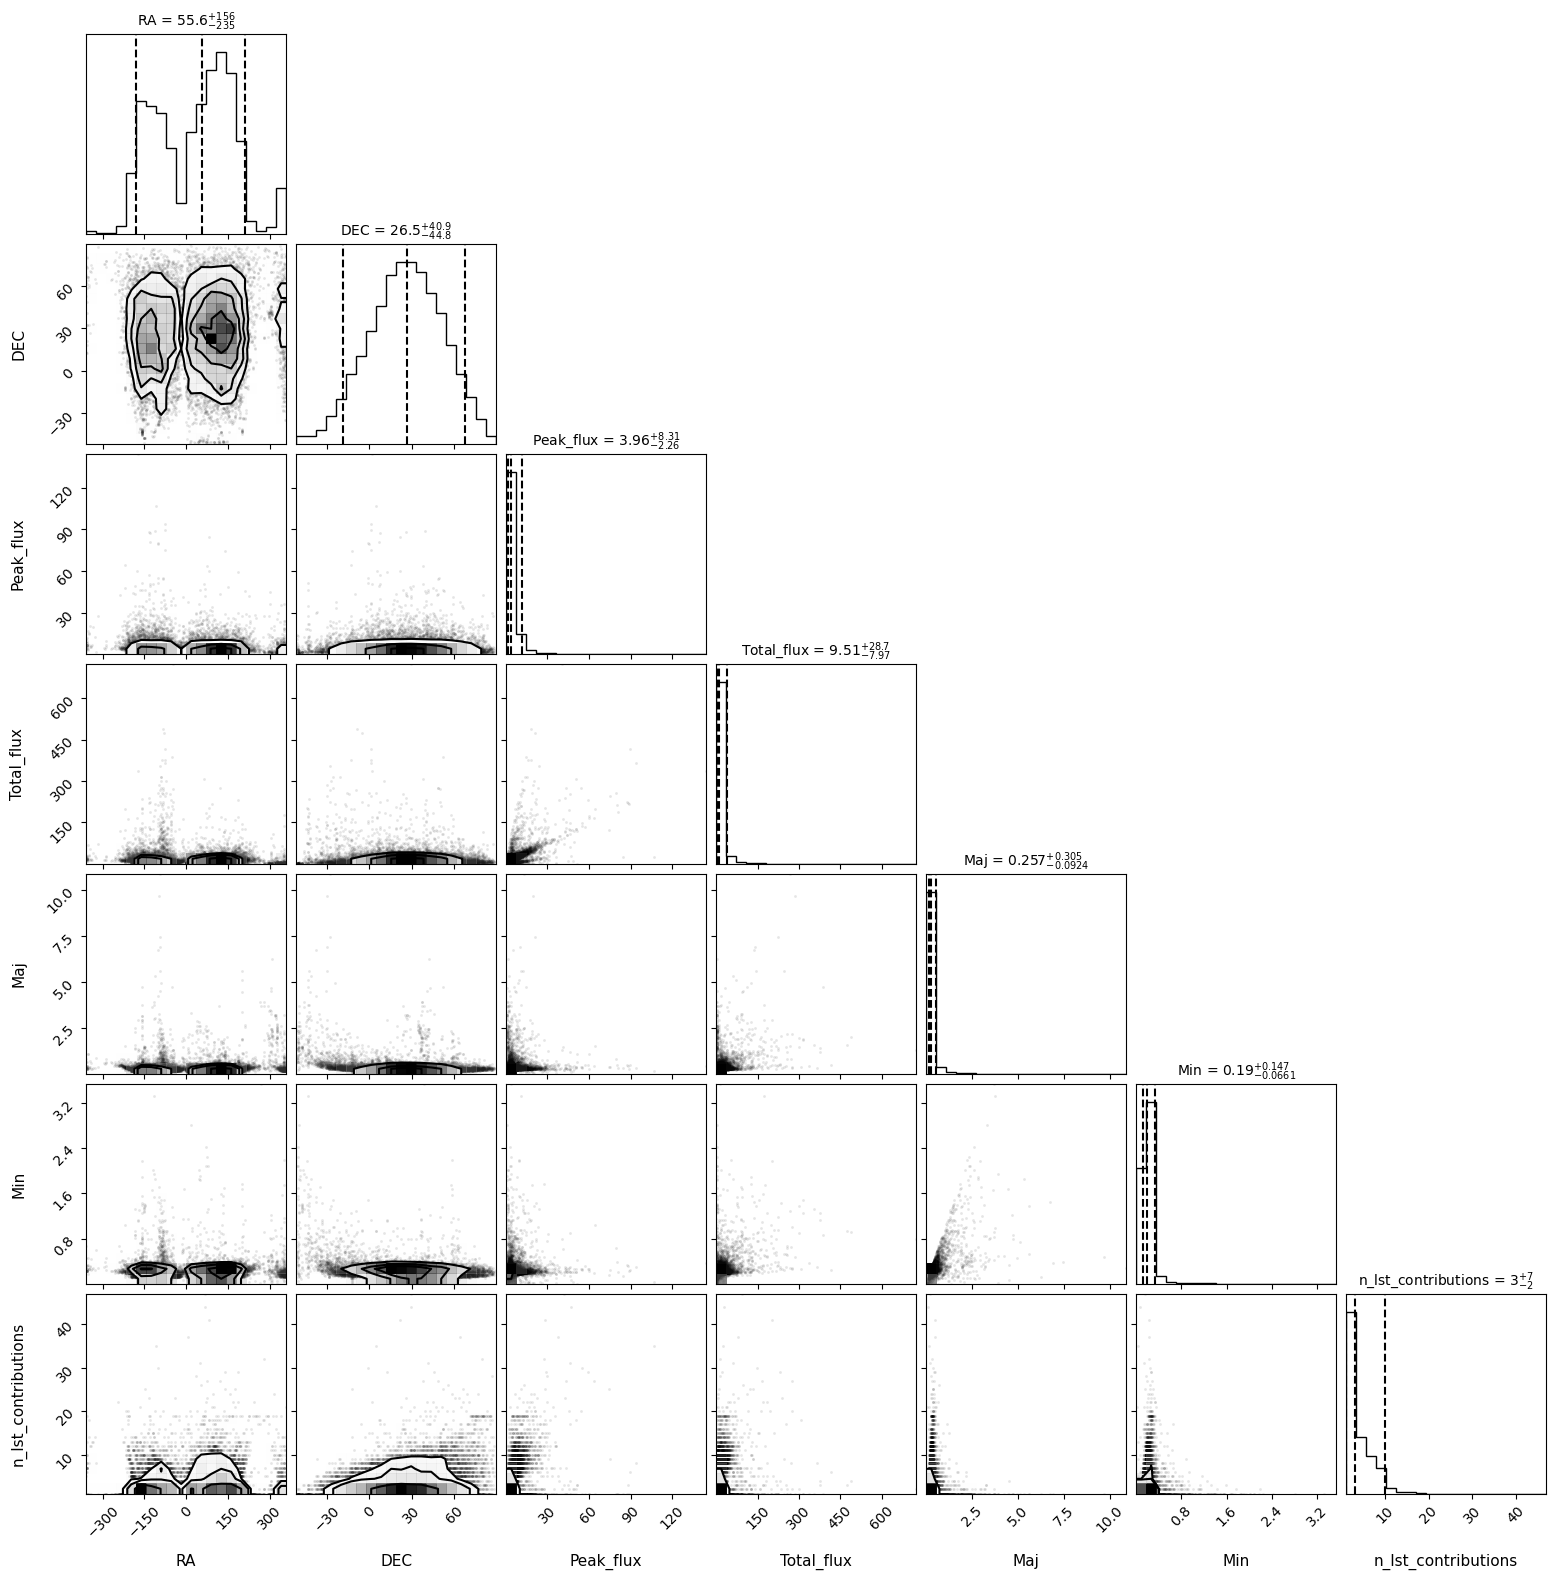

In [14]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

plt.show()